# Install Enviroments

In [ ]:
!pip install --upgrade transformers datasets sacrebleu rouge-score

In [ ]:
!pip install peft

In [ ]:
!pip install protobuf==3.20.3 --force-reinstall

# **Import Libraries**

In [4]:
import logging
from pathlib import Path

import string
import unicodedata
import re
import numpy as np
import math
import pandas as pd
import torch
import transformers
import peft
import sacrebleu
from datasets import Dataset, DatasetDict
from transformers import (
    AutoModelForCausalLM,
    AutoModelForSeq2SeqLM,
    AutoTokenizer,
    DataCollatorForLanguageModeling,
    DataCollatorForSeq2Seq,
    Trainer,
    TrainingArguments,
)
from rouge_score import rouge_scorer
import gc
logging.basicConfig(level=logging.INFO)
logger = logging.getLogger(__name__)

2025-11-23 13:35:17.032810: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1763904917.214142      48 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1763904917.264296      48 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


In [5]:
from transformers import Seq2SeqTrainingArguments, Seq2SeqTrainer, AutoTokenizer, AutoModelForSeq2SeqLM, DataCollatorForSeq2Seq

In [6]:
print(torch.__version__)
print(transformers.__version__)
print(peft.__version__)

2.6.0+cu124
4.57.1
0.16.0


# **Functions**

## Clean data Function

In [8]:
def clean_text(text, trans_table):
    
    if not isinstance(text, str):
        return ""

    text = unicodedata.normalize('NFC', text)

    text = text.replace('\u00A0', ' ').replace('\n', ' ').replace('\r', ' ')

    text = text.replace('"', '"').replace('"', '"')
    text = text.replace(''', "'").replace(''', "'")

    text = text.replace('–', '-').replace('—', '-').replace('…', '...')

    text = text.translate(trans_table)

    text = re.sub(r'\s+', ' ', text)

    return text.lower().strip()

## Clean dataset Function

In [9]:
def clean_dataset(df):
    
    print(f"Số dòng ban đầu: {len(df)}")

    df = df.dropna(subset=['en_sents', 'vi_sents']).copy()
    print(f"Sau khi loại NaN: {len(df)}")

    punctuation = string.punctuation + '""''–—…'
    trans_table = str.maketrans('', '', punctuation)

    df['en_sents'] = df['en_sents'].apply(lambda x: clean_text(x, trans_table))
    df['vi_sents'] = df['vi_sents'].apply(lambda x: clean_text(x, trans_table))

    df = df[(df['en_sents'].str.len() > 0) & (df['vi_sents'].str.len() > 0)].copy()
    print(f"Sau khi loại dòng trống: {len(df)}")

    df = df.drop_duplicates(subset=['en_sents', 'vi_sents']).reset_index(drop=True)
    print(f"Sau khi loại trùng lặp: {len(df)}")

    return df

In [10]:
def load_data(base_dir):
    
    datasets = {}
    for split in ["train", "valid", "test"]:
        path = base_dir / f"{split}.csv"
        if not path.exists():
            raise FileNotFoundError(f"Missing split at {path}")

        print(f"\n=== Cleaning {split} split ===")
        df = pd.read_csv(path)
        df = clean_dataset(df)

        datasets[split] = Dataset.from_pandas(df[["en_sents", "vi_sents"]])

    return DatasetDict(datasets)

In [11]:
def expand_bidirectional(dataset: Dataset) -> Dataset:

    df = dataset.to_pandas()
    records = []
    for _, row in df.iterrows():
        en = row["en_sents"]
        vi = row["vi_sents"]
        if pd.isna(en) or pd.isna(vi):
            continue
        records.append({
            "source": vi,
            "target": en,
            "direction": "vi2en",
        })
        records.append({
            "source": en,
            "target": vi,
            "direction": "en2vi",
        })
    return Dataset.from_pandas(pd.DataFrame(records))

In [12]:
def tokenize_encoder_decoder_batch(examples, tokenizer, max_input_length=128, max_target_length=128):
    
    inputs = []
    targets = []
    for src, tgt, direction in zip(examples["source"], examples["target"], examples["direction"]):
        prefix = (
            "Translate Vietnamese to English:" if direction == "vi2en" else "Translate English to Vietnamese:"
        )
        inputs.append(f"{prefix} {src}")
        targets.append(tgt)

    model_inputs = tokenizer(
        inputs,
        max_length=max_input_length,
        truncation=True,
        padding="max_length",
    )
    labels = tokenizer(
        targets,
        max_length=max_target_length,
        truncation=True,
        padding="max_length",
    )["input_ids"]

    labels = [
        [label if label != tokenizer.pad_token_id else -100 for label in label_row]
        for label_row in labels
    ]
    model_inputs["labels"] = labels
    return model_inputs

In [ ]:
def tokenize_decoder_only_batch(examples, tokenizer, max_length=256):
    input_ids_list = []
    labels_list = []

    for src, tgt, direction in zip(examples["source"], examples["target"], examples["direction"]):
        
        if pd.isna(src) or pd.isna(tgt):
            continue

        prefix = "Translate Vietnamese to English" if direction == "vi2en" else "Translate English to Vietnamese"
        prompt = f"{prefix}.\nSource: {src}\nTarget:"
        
        
        full_text = f"{prompt} {tgt}{tokenizer.eos_token}"


        tokenized_full = tokenizer(
            full_text, 
            add_special_tokens=False, 
            truncation=True, 
            max_length=max_length
        )
        input_ids = tokenized_full["input_ids"]

        tokenized_prompt = tokenizer(
            prompt, 
            add_special_tokens=False
        )
        prompt_ids = tokenized_prompt["input_ids"]
        prompt_len = len(prompt_ids)
        
        labels = list(input_ids) 
        
        if prompt_len < len(labels):
            
            labels[:prompt_len] = [-100] * prompt_len
        else:
            
            labels[:] = [-100] * len(labels)

        input_ids_list.append(input_ids)
        labels_list.append(labels)

    return {"input_ids": input_ids_list, "labels": labels_list}

In [14]:
def compute_metrics_seq2seq(eval_pred, tokenizer):
   
    predictions = eval_pred.predictions
    labels = eval_pred.label_ids

    if isinstance(predictions, tuple):
        predictions = predictions[0]

    predictions = np.where(predictions != -100, predictions, tokenizer.pad_token_id)

    decoded_preds = tokenizer.batch_decode(predictions, skip_special_tokens=True)

    decoded_labels = []
    for label_ids in labels:
        filtered = [l for l in label_ids if l != -100]
        decoded_labels.append(tokenizer.decode(filtered, skip_special_tokens=True))

    bleu = sacrebleu.corpus_bleu(decoded_preds, [decoded_labels])

    scorer = rouge_scorer.RougeScorer(['rouge1', 'rouge2', 'rougeL'], use_stemmer=False)
    rouge_scores = {'rouge1': [], 'rouge2': [], 'rougeL': []}

    for pred, label in zip(decoded_preds, decoded_labels):
        scores = scorer.score(label, pred)
        rouge_scores['rouge1'].append(scores['rouge1'].fmeasure)
        rouge_scores['rouge2'].append(scores['rouge2'].fmeasure)
        rouge_scores['rougeL'].append(scores['rougeL'].fmeasure)

    return {
        "bleu": bleu.score / 100,      
        "rouge1": np.mean(rouge_scores['rouge1']), 
        "rouge2": np.mean(rouge_scores['rouge2']), 
        "rougeL": np.mean(rouge_scores['rougeL']), 
    }

In [15]:
from tqdm.auto import tqdm

In [ ]:
def evaluate_decoder_generation(model, tokenizer, dataset, max_new_tokens=128, batch_size=8):
    
    model.eval()
    
    original_padding_side = tokenizer.padding_side
    tokenizer.padding_side = 'left'  
    
    all_predictions = []
    all_references = []

    df = dataset.to_pandas()
    total_samples = len(df)


    progress_bar = tqdm(range(0, total_samples, batch_size), desc="Generating", unit="batch")

    for i in progress_bar:
        batch = df.iloc[i:i+batch_size]

        # prompts (KHÔNG có target)
        prompts = []
        references = []
        for _, row in batch.iterrows():
            src = row['source']
            tgt = row['target']
            direction = row['direction']

            prefix = "Translate Vietnamese to English" if direction == "vi2en" else "Translate English to Vietnamese"
            prompt = f"{prefix}.\nSource: {src}\nTarget:"

            prompts.append(prompt)
            references.append(tgt)

        inputs = tokenizer(
            prompts, 
            return_tensors="pt", 
            padding=True, 
            truncation=True, 
            max_length=512
        )
        inputs = {k: v.to(model.device) for k, v in inputs.items()}

        with torch.no_grad():
            outputs = model.generate(
                **inputs,
                max_new_tokens=max_new_tokens,
                num_beams=1,          
                do_sample=False,
                pad_token_id=tokenizer.pad_token_id,
                eos_token_id=tokenizer.eos_token_id,
                
            )

        
        for j, output in enumerate(outputs):
            prompt_len = len(inputs['input_ids'][j])
            generated_ids = output[prompt_len:]  
            generated_text = tokenizer.decode(generated_ids, skip_special_tokens=True)

            if "Source:" in generated_text:
                generated_text = generated_text.split("Source:")[0]
            if "Translate" in generated_text:
                generated_text = generated_text.split("Translate")[0]

            all_predictions.append(generated_text.strip())

        all_references.extend(references)

    tokenizer.padding_side = original_padding_side

    print("Đang tính điểm BLEU/ROUGE...")

    bleu = sacrebleu.corpus_bleu(all_predictions, [all_references])

    scorer = rouge_scorer.RougeScorer(['rouge1', 'rouge2', 'rougeL'], use_stemmer=False)
    rouge_scores = {'rouge1': [], 'rouge2': [], 'rougeL': []}

    for pred, ref in zip(all_predictions, all_references):
        scores = scorer.score(ref, pred)
        rouge_scores['rouge1'].append(scores['rouge1'].fmeasure)
        rouge_scores['rouge2'].append(scores['rouge2'].fmeasure)
        rouge_scores['rougeL'].append(scores['rougeL'].fmeasure)

    return {
        "bleu": bleu.score / 100,  # Về thang 0-1
        "rouge1": np.mean(rouge_scores['rouge1']),
        "rouge2": np.mean(rouge_scores['rouge2']),
        "rougeL": np.mean(rouge_scores['rougeL']),
    }

In [17]:
def train_encoder_decoder(
    dataset_dict,
    model_checkpoint,
    tokenizer_checkpoint,
    output_dir,
    max_input_length=128,
    max_target_length=128,
    num_train_epochs=1,
    batch_size=8,              
    learning_rate=2e-5,
    gradient_accumulation_steps=4,
):
    output_dir = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)

    tokenizer = AutoTokenizer.from_pretrained(tokenizer_checkpoint)
    if tokenizer.pad_token is None:
        tokenizer.pad_token = tokenizer.eos_token

    expanded = DatasetDict(
        {split: expand_bidirectional(dataset_dict[split]) for split in dataset_dict}
    )

    tokenized = expanded.map(
        lambda batch: tokenize_encoder_decoder_batch(
            batch, tokenizer, max_input_length, max_target_length
        ),
        batched=True,
        remove_columns=expanded["train"].column_names,
        load_from_cache_file=False,
    )

    model = AutoModelForSeq2SeqLM.from_pretrained(model_checkpoint)
    model.gradient_checkpointing_enable() 
    model.config.use_cache = False

    data_collator = DataCollatorForSeq2Seq(tokenizer, model=model)

    training_args = Seq2SeqTrainingArguments(
        output_dir=str(output_dir),

        per_device_train_batch_size=batch_size,
        gradient_accumulation_steps=gradient_accumulation_steps,
        num_train_epochs=num_train_epochs,
        learning_rate=learning_rate,
        weight_decay=0.01,

        eval_strategy="epoch",
        save_strategy="epoch",
        save_total_limit=1,
        per_device_eval_batch_size=batch_size,

        predict_with_generate=True,
        eval_accumulation_steps=1,      
        generation_max_length=max_target_length,

        fp16=True,                       
        logging_dir=str(output_dir / "logs"),
        logging_steps=50,
        report_to="none",
        optim="adamw_torch",
        load_best_model_at_end=True,
        metric_for_best_model="eval_bleu",
    )

    trainer = Seq2SeqTrainer(
        model=model,
        args=training_args,
        train_dataset=tokenized["train"],
        eval_dataset=tokenized["valid"],
        tokenizer=tokenizer,
        data_collator=data_collator,
        compute_metrics=lambda preds: compute_metrics_seq2seq(preds, tokenizer),
    )

    return trainer

In [18]:
from transformers import (
    AutoTokenizer, 
    AutoModelForCausalLM, 
    DataCollatorWithPadding, 
    TrainingArguments, 
    Trainer
)

In [ ]:
def train_decoder_only(
    dataset_dict,
    model_checkpoint,
    tokenizer_checkpoint,
    output_dir,
    max_length=128,
    num_train_epochs=1,
    batch_size=16,
    learning_rate=2e-5,
    gradient_accumulation_steps=1,
):
    output_dir = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)

    tokenizer = AutoTokenizer.from_pretrained(tokenizer_checkpoint)
    tokenizer.padding_side = "right" 
    
    if tokenizer.pad_token is None:
        tokenizer.pad_token = tokenizer.eos_token

    expanded = DatasetDict({
        split: expand_bidirectional(dataset_dict[split])
        for split in dataset_dict
    })

    tokenized = expanded.map(
        lambda batch: tokenize_decoder_only_batch(batch, tokenizer, max_length),
        batched=True,
        remove_columns=expanded["train"].column_names,
        load_from_cache_file=False,
    )

    model = AutoModelForCausalLM.from_pretrained(model_checkpoint)
    model.config.pad_token_id = tokenizer.pad_token_id
    model.config.eos_token_id = tokenizer.eos_token_id
    model.config.use_cache = False  
    
    model.resize_token_embeddings(len(tokenizer))

    def causal_data_collator(features):

        labels = [feature.pop("labels") for feature in features] if "labels" in features[0] else None

        batch = DataCollatorWithPadding(tokenizer, return_tensors="pt")(features)

        if labels is not None:
            
            max_label_length = batch["input_ids"].shape[1]
            padded_labels = []

            for l in labels:
            
                remainder = max_label_length - len(l)
                if remainder < 0:
                   
                    l = l[:max_label_length]
                else:
                    l = l + [-100] * remainder
                    
                padded_labels.append(l)

            batch["labels"] = torch.tensor(padded_labels, dtype=torch.long)

        return batch

    training_args = TrainingArguments(
        output_dir=str(output_dir),
        per_device_train_batch_size=batch_size,
        gradient_accumulation_steps=gradient_accumulation_steps,
        num_train_epochs=num_train_epochs,
        learning_rate=learning_rate,
        weight_decay=0.01,
        fp16=True,  
        optim="adamw_torch",
        eval_strategy="epoch",
        save_strategy="epoch",
        per_device_eval_batch_size=batch_size,
        logging_steps=50,
        save_total_limit=1,
        group_by_length=True,      
        gradient_checkpointing=True, 
        report_to="none",
    )

    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=tokenized["train"],
        eval_dataset=tokenized["valid"],
        data_collator=causal_data_collator,
        processing_class=tokenizer 
    )

    return trainer

In [19]:
AUGMENT_DIR = Path("/kaggle/input/e-v-augment")
ORIGINAL_DIR = Path("/kaggle/input/e-v-original")
SPLITS = ["train", "valid", "test"]
augmented_splits = load_data(AUGMENT_DIR)
original_splits = load_data(ORIGINAL_DIR)

for label, dataset_dict in [("Augmented", augmented_splits), ("Original", original_splits)]:
    logger.info("Split stats for %s dataset:", label)
    for split in SPLITS:
        logger.info("  %s: %d rows", split, len(dataset_dict[split]))


=== Cleaning train split ===
Số dòng ban đầu: 11998
Sau khi loại NaN: 11998
Sau khi loại dòng trống: 11998
Sau khi loại trùng lặp: 11998

=== Cleaning valid split ===
Số dòng ban đầu: 1499
Sau khi loại NaN: 1499
Sau khi loại dòng trống: 1499
Sau khi loại trùng lặp: 1499

=== Cleaning test split ===
Số dòng ban đầu: 1501
Sau khi loại NaN: 1501
Sau khi loại dòng trống: 1501
Sau khi loại trùng lặp: 1501

=== Cleaning train split ===
Số dòng ban đầu: 7999
Sau khi loại NaN: 7999
Sau khi loại dòng trống: 7999
Sau khi loại trùng lặp: 7999

=== Cleaning valid split ===
Số dòng ban đầu: 999
Sau khi loại NaN: 999
Sau khi loại dòng trống: 999
Sau khi loại trùng lặp: 999

=== Cleaning test split ===
Số dòng ban đầu: 1001
Sau khi loại NaN: 1001
Sau khi loại dòng trống: 1001
Sau khi loại trùng lặp: 1001


In [22]:
pd.set_option('display.max_colwidth', None)

print("Dữ liệu Original (Train )")
df_view = original_splits["train"].to_pandas().head(5)
display(df_view)


Dữ liệu Original (Train )


,en_sents,vi_sents
0,we must give it time,chúng ta phải cho nó thời gian
1,will you look over my report,bạn sẽ xem qua báo cáo của tôi
2,is there something we can do,chúng ta có thể làm gì
3,professor white published his first book last year,giáo sư trắng xuất bản cuốn sách đầu tiên của ông năm ngoái
4,why does tom want us to do this,tại sao tom muốn chúng ta làm điều này


In [23]:
print("Dữ liệu Augmented (Train )")
df_aug_view = augmented_splits["train"].to_pandas().head(5)
display(df_aug_view)

Dữ liệu Augmented (Train )


,en_sents,vi_sents
0,i heard the news that you purchased a new car,tôi nghe tin là bạn đã mua một chiếc xe hơi mới
1,science has brought about many changes in our lives,khoa học đã mang lại nhiều thay đổi trong cuộc sống của chúng ta
2,tom didnt get there in time,tom đã không đến đó kịp thời
3,here are the pictures from last night,đây là những hình ảnh từ tối qua
4,thats the least of your problems right now,đó là vấn đề ít nhất của bạn lúc này


In [ ]:
nums=5

In [ ]:
vit5_orig_trainer = train_encoder_decoder(
    original_splits,                
    model_checkpoint="VietAI/vit5-base",
    tokenizer_checkpoint="VietAI/vit5-base",
    output_dir=Path("outputs") / "vit5_original",
    max_input_length=128,            
    max_target_length=128,
    num_train_epochs=nums,
    batch_size=16,                    
    gradient_accumulation_steps=2,
    learning_rate=0.0001,
)
vit5_orig_trainer.train()

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json: 0.00B [00:00, ?B/s]

spiece.model:   0%|          | 0.00/820k [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json: 0.00B [00:00, ?B/s]

...

model.safetensors:   0%|          | 0.00/904M [00:00<?, ?B/s]

/tmp/ipython-input-3541282768.py:73: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Seq2SeqTrainer.__init__`. Use `processing_class` instead.
  trainer = Seq2SeqTrainer(


Epoch,Training Loss,Validation Loss,Bleu,Rouge1,Rouge2,Rougel
1,2.033000,1.769643,0.260045,0.568821,0.345569,0.551149
2,1.500000,1.416715,0.344233,0.643098,0.438896,0.628220
3,1.025300,1.323412,0.386169,0.673464,0.476757,0.659476
4,0.741300,1.316135,0.408219,0.686595,0.495008,0.671978
5,0.594600,1.381470,0.418377,0.688581,0.501280,0.674295


There were missing keys in the checkpoint model loaded: ['encoder.embed_tokens.weight', 'decoder.embed_tokens.weight', 'lm_head.weight'].


TrainOutput(global_step=2500, training_loss=1.338098065185547, metrics={'train_runtime': 2963.1405, 'train_samples_per_second': 26.995, 'train_steps_per_second': 0.844, 'total_flos': 1.21776354164736e+16, 'train_loss': 1.338098065185547, 'epoch': 5.0})

In [ ]:
vit5_orig_metrics = vit5_orig_trainer.evaluate()
logger.info("ViT5 Original - BLEU=%.2f, ROUGE-1=%.2f, ROUGE-2=%.2f, ROUGE-L=%.2f",
            vit5_orig_metrics["eval_bleu"],
            vit5_orig_metrics["eval_rouge1"],
            vit5_orig_metrics["eval_rouge2"],
            vit5_orig_metrics["eval_rougeL"])

In [ ]:
vit5_orig_trainer.save_model()

In [ ]:
del vit5_orig_trainer
gc.collect()
torch.cuda.empty_cache()

In [ ]:
vit5_aug_trainer = train_encoder_decoder(
    augmented_splits,                
    model_checkpoint="VietAI/vit5-base",
    tokenizer_checkpoint="VietAI/vit5-base",
    output_dir=Path("outputs") / "vit5_augmented",
    max_input_length=128,
    max_target_length=128,
    num_train_epochs=nums,
    batch_size=16,
    gradient_accumulation_steps=2,
    learning_rate=0.0001,
)

vit5_aug_trainer.train()

Tokenizing data for vit5_augmented...


Map:   0%|          | 0/23996 [00:00<?, ? examples/s]

Map:   0%|          | 0/2998 [00:00<?, ? examples/s]

Map:   0%|          | 0/3002 [00:00<?, ? examples/s]

/tmp/ipython-input-3541282768.py:73: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Seq2SeqTrainer.__init__`. Use `processing_class` instead.
  trainer = Seq2SeqTrainer(


Epoch,Training Loss,Validation Loss,Bleu,Rouge1,Rouge2,Rougel
1,1.946600,1.675617,0.266648,0.579314,0.361410,0.557395
2,1.382800,1.361380,0.355599,0.649968,0.447508,0.631140
3,0.974700,1.262871,0.401044,0.677557,0.486056,0.659585
4,0.707800,1.259071,0.419269,0.693155,0.507361,0.674455
5,0.558800,1.301628,0.428119,0.699408,0.515060,0.682204


There were missing keys in the checkpoint model loaded: ['encoder.embed_tokens.weight', 'decoder.embed_tokens.weight', 'lm_head.weight'].


TrainOutput(global_step=3750, training_loss=1.2664697402954102, metrics={'train_runtime': 4542.3477, 'train_samples_per_second': 26.414, 'train_steps_per_second': 0.826, 'total_flos': 1.82656919273472e+16, 'train_loss': 1.2664697402954102, 'epoch': 5.0})

In [ ]:
vit5_aug_metrics = vit5_aug_trainer.evaluate()
logger.info("ViT5 Augmented - BLEU=%.2f, ROUGE-1=%.2f, ROUGE-2=%.2f, ROUGE-L=%.2f",
            vit5_aug_metrics["eval_bleu"],
            vit5_aug_metrics["eval_rouge1"],
            vit5_aug_metrics["eval_rouge2"],
            vit5_aug_metrics["eval_rougeL"])

In [ ]:
vit5_aug_trainer.save_model()

In [ ]:
del vit5_aug_trainer
gc.collect()
torch.cuda.empty_cache()  

In [19]:
nums=2

In [ ]:
qwen_orig_trainer = train_decoder_only(
    original_splits,
    model_checkpoint="Qwen/Qwen2.5-0.5B",
    tokenizer_checkpoint="Qwen/Qwen2.5-0.5B",
    output_dir=Path("outputs") / "qwen_original",
    max_length=128,
    num_train_epochs=nums,

    batch_size=8,
    gradient_accumulation_steps=4,
    learning_rate=2e-4,
)

qwen_orig_trainer.train()
qwen_orig_trainer.save_model()

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Đang tokenize dữ liệu...


...

model.safetensors:   0%|          | 0.00/988M [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/138 [00:00<?, ?B/s]

/tmp/ipykernel_48/462209499.py:97: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(
The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None, 'pad_token_id': 151643}.
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` b

Epoch,Training Loss,Validation Loss
1,1.392600,1.556036
2,0.469600,1.152528


huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The 

In [22]:
import math
import json
import os

In [24]:
from tqdm.auto import tqdm

In [ ]:
raw_valid = original_splits["valid"]

target_split = expand_bidirectional(raw_valid)

valid_dataset_tokenized = target_split.map(
    lambda batch: tokenize_decoder_only_batch(batch, qwen_orig_trainer.tokenizer, max_length=128),
    batched=True,
    remove_columns=target_split.column_names,
    load_from_cache_file=False
)


valid_metrics = qwen_orig_trainer.evaluate(eval_dataset=valid_dataset_tokenized)

valid_loss = valid_metrics['eval_loss']
perplexity = math.exp(valid_loss)


qwen_orig_gen_metrics = evaluate_decoder_generation(
    model=qwen_orig_trainer.model,
    tokenizer=qwen_orig_trainer.tokenizer,
    dataset=target_split,         
    max_new_tokens=128,
    batch_size=32,
)


Map:   0%|          | 0/1998 [00:00<?, ? examples/s]

Trainer.tokenizer is now deprecated. You should use Trainer.processing_class instead.
Trainer.tokenizer is now deprecated. You should use Trainer.processing_class instead.
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
Trainer.tokenizer is now deprecated. You should use Trainer.processing_class instead.


🚀 Bắt đầu đánh giá trên 1998 mẫu...


Generating:   0%|          | 0/63 [00:00<?, ?batch/s]

Đang tính điểm BLEU/ROUGE...


In [26]:
print(f"► Loss: {valid_loss:.4f} | PPL: {perplexity:.4f} | BLEU: {qwen_orig_gen_metrics['bleu']:.4f}")

► Loss: 1.1527 | PPL: 3.1667 | BLEU: 0.4553


In [ ]:
del qwen_orig_trainer
gc.collect()
torch.cuda.empty_cache()

In [ ]:
qwen_aug_trainer = train_decoder_only(
    augmented_splits,               
    model_checkpoint="Qwen/Qwen2.5-0.5B",
    tokenizer_checkpoint="Qwen/Qwen2.5-0.5B",
    output_dir=Path("outputs") / "qwen_augmented",
    max_length=128,
    num_train_epochs=nums,

    batch_size=8,                  
    gradient_accumulation_steps=4,   
    learning_rate=2e-4,
)
qwen_aug_trainer.train()
qwen_aug_trainer.save_model()

Đang tokenize dữ liệu...


Map:   0%|          | 0/23996 [00:00<?, ? examples/s]

Map:   0%|          | 0/2998 [00:00<?, ? examples/s]

Map:   0%|          | 0/3002 [00:00<?, ? examples/s]

/tmp/ipykernel_48/462209499.py:97: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(
The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None, 'pad_token_id': 151643}.
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` b

Epoch,Training Loss,Validation Loss
1,1.367100,1.468501
2,0.502000,1.116028


huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The 

In [ ]:
raw_test = original_splits["valid"]

target_split = expand_bidirectional(raw_test)

test_dataset_tokenized = target_split.map(
    lambda batch: tokenize_decoder_only_batch(batch, qwen_aug_trainer.tokenizer, max_length=128),
    batched=True,
    remove_columns=target_split.column_names,
    load_from_cache_file=False
)


test_metrics = qwen_aug_trainer.evaluate(eval_dataset=test_dataset_tokenized)

test_loss = test_metrics['eval_loss']
perplexity = math.exp(test_loss)

qwen_aug_gen_metrics = evaluate_decoder_generation(
    model=qwen_aug_trainer.model,
    tokenizer=qwen_aug_trainer.tokenizer,
    dataset=target_split,         
    max_new_tokens=128,
    batch_size=32,                
)

Map:   0%|          | 0/2002 [00:00<?, ? examples/s]

Trainer.tokenizer is now deprecated. You should use Trainer.processing_class instead.
Trainer.tokenizer is now deprecated. You should use Trainer.processing_class instead.
Trainer.tokenizer is now deprecated. You should use Trainer.processing_class instead.
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


Trainer.tokenizer is now deprecated. You should use Trainer.processing_class instead.


🚀 Bắt đầu đánh giá trên 2002 mẫu...


Generating:   0%|          | 0/63 [00:00<?, ?batch/s]

Đang tính điểm BLEU/ROUGE...


In [33]:
print(f"► Loss: {test_loss:.4f} | PPL: {perplexity:.4f} | BLEU: {qwen_aug_gen_metrics['bleu']:.4f}")

► Loss: 1.0268 | PPL: 2.7922 | BLEU: 0.5110


In [ ]:
del qwen_aug_trainer
gc.collect()
torch.cuda.empty_cache()

# Test

In [ ]:
!pip install google-generativeai

In [25]:
import google.generativeai as genai
import time

In [26]:
def setup_gemini_api(api_key: str):
    genai.configure(api_key=api_key)
    
    return genai.GenerativeModel('models/gemini-2.0-flash')

In [ ]:
def evaluate_translation_with_llm(
    source: str,
    reference: str,
    prediction: str,
    direction: str,
    model: object
):
    """
    Đánh giá chất lượng dịch bằng Gemini với 6 tiêu chí chi tiết.
    """
    
    src_lang = "Vietnamese" if direction == "vi2en" else "English"
    tgt_lang = "English" if direction == "vi2en" else "Vietnamese"
    
    prompt = f"""You are an expert translation evaluator. Evaluate the following {src_lang} to {tgt_lang} translation.

**Source ({src_lang}):** {source}
**Reference:** {reference}
**Model Prediction:** {prediction}

Evaluate on these criteria (score 0-10):

1. **Fluency**: Is the text grammatically correct and natural?
2. **Adequacy**: Does it preserve the original meaning completely?
3. **Coherence**: Is the translation logical and consistent?
4. **Relevance**: Does the output directly address the translation task (ignoring prompt repetition or unrelated chat)?
5. **Factuality**: Does the translation maintain factual accuracy (numbers, names, entities) without hallucination?
6. **Overall**: General quality score.

Return JSON ONLY in this format:
{{
    "fluency": <score>,
    "adequacy": <score>,
    "coherence": <score>,
    "relevance": <score>,
    "factuality": <score>,
    "overall": <score>,
    "reasoning": "<brief explanation>"
}}"""

    try:
        response = model.generate_content(prompt)
        
        if not response.parts:
            return {k: 0.0 for k in ["fluency", "adequacy", "coherence", "relevance", "factuality", "overall"]}

        result_text = response.text.strip()
        
        json_match = re.search(r'\{.*\}', result_text, re.DOTALL)
        if json_match:
            json_str = json_match.group(0)
        else:
            json_str = result_text.replace("```json", "").replace("```", "").strip()

        result = json.loads(json_str)
        
        return {
            "fluency": float(result.get("fluency", 0)) / 10.0,
            "adequacy": float(result.get("adequacy", 0)) / 10.0,
            "coherence": float(result.get("coherence", 0)) / 10.0,
            "relevance": float(result.get("relevance", 0)) / 10.0,
            "factuality": float(result.get("factuality", 0)) / 10.0,
            "overall": float(result.get("overall", 0)) / 10.0,
            "reasoning": result.get("reasoning", "No reasoning provided")
        }

    except Exception as e:
        print(f" LLM Error: {e}")
        return {k: 0.0 for k in ["fluency", "adequacy", "coherence", "relevance", "factuality", "overall"]}

In [ ]:
GEMINI_API_KEY = "your_gemini_api_key"
gemini_model = setup_gemini_api(GEMINI_API_KEY)

In [29]:
MODELS_CONFIG = {
    "en-de Original":  "/kaggle/input/vit5-original/transformers/default/1",
    "en-de Augmented": "/kaggle/input/vit5-augmented/transformers/default/1",
    "de1 Original":  "/kaggle/input/qwen-original/transformers/default/1",
    "de1 Augmented": "/kaggle/input/qwen-augmented/transformers/default/1"
}

GLOBAL_RESULTS = {}
SAMPLE_LOGS = {}

def clean_memory():
    if 'model' in globals(): del globals()['model']
    if 'tokenizer' in globals(): del globals()['tokenizer']
    gc.collect()
    torch.cuda.empty_cache()

def calc_metrics(preds, refs):
    bleu = sacrebleu.corpus_bleu(preds, [refs]).score / 100
    
    scorer = rouge_scorer.RougeScorer(['rouge1', 'rouge2', 'rougeL'], use_stemmer=False)
    
    r1 = np.mean([scorer.score(r, p)['rouge1'].fmeasure for p, r in zip(preds, refs)])
    r2 = np.mean([scorer.score(r, p)['rouge2'].fmeasure for p, r in zip(preds, refs)]) # <--- Mới thêm
    rl = np.mean([scorer.score(r, p)['rougeL'].fmeasure for p, r in zip(preds, refs)])
    
    return {
        "BLEU": bleu, 
        "ROUGE-1": r1, 
        "ROUGE-2": r2, 
        "ROUGE-L": rl
    }

def get_sentence_scores(pred, ref):
    s_bleu = sacrebleu.sentence_bleu(pred, [ref]).score / 100
    scorer = rouge_scorer.RougeScorer(['rougeL'], use_stemmer=False)
    s_rouge = scorer.score(ref, pred)['rougeL'].fmeasure
    return s_bleu, s_rouge

In [30]:
raw_test = original_splits["test"]
test_expanded = expand_bidirectional(raw_test)
eval_df = test_expanded.to_pandas()
print(f"Tổng số câu: {len(eval_df)} mẫu .")

Tổng số câu: 2002 mẫu .


### Encoder-Decoder

#### ViT5 Original Evaluaion

In [31]:
from transformers import T5Tokenizer, T5Config, AutoModelForSeq2SeqLM

In [ ]:
model_name = "en-de Original" 
path = MODELS_CONFIG[model_name]
batch_size = 32

tokenizer = T5Tokenizer.from_pretrained(path)
model = AutoModelForSeq2SeqLM.from_pretrained(path, device_map="auto")
model.eval()

preds, refs = [], []

for i in tqdm(range(0, len(eval_df), batch_size), desc=f"Eval {model_name}"):
    batch = eval_df.iloc[i:i+batch_size]
    batch_refs = batch['target'].tolist()
    
    batch_inputs = []
    for _, row in batch.iterrows():
        prefix = "Translate Vietnamese to English:" if row['direction'] == "vi2en" else "Translate English to Vietnamese:"
        batch_inputs.append(f"{prefix} {row['source']}")
        
    tokens = tokenizer(
        batch_inputs, 
        return_tensors="pt", 
        padding=True, 
        truncation=True, 
        max_length=256 
    ).to("cuda")
    
    with torch.no_grad():
        outputs = model.generate(
            **tokens, 
            max_new_tokens=128, 
            num_beams=4, 
            early_stopping=True
        )
    
    decoded = tokenizer.batch_decode(outputs, skip_special_tokens=True)
    preds.extend(decoded)
    refs.extend(batch_refs)

scores = calc_metrics(preds, refs)
scores["PPL"] = 0.0 
GLOBAL_RESULTS[model_name] = scores

print(f"\n {model_name} RESULTS:")
print(f"   BLEU:    {scores['BLEU']:.4f}")
print(f"   ROUGE-1: {scores['ROUGE-1']:.4f}")
print(f"   ROUGE-2: {scores['ROUGE-2']:.4f}")
print(f"   ROUGE-L: {scores['ROUGE-L']:.4f}")

You are using the default legacy behaviour of the <class 'transformers.models.t5.tokenization_t5.T5Tokenizer'>. This is expected, and simply means that the `legacy` (previous) behavior will be used so nothing changes for you. If you want to use the new behaviour, set `legacy=False`. This should only be set if you understand what it means, and thoroughly read the reason why this was added as explained in https://github.com/huggingface/transformers/pull/24565


Eval en-de Original:   0%|          | 0/63 [00:00<?, ?it/s]


✅ en-de Original RESULTS:
   BLEU:    0.4454
   ROUGE-1: 0.7050
   ROUGE-2: 0.5297
   ROUGE-L: 0.6925


In [35]:
import json

In [ ]:
for i in range(6):

    row = eval_df.iloc[i]
    source_text = row['source']
    target_text = row['target'] 
    direction = row['direction']
    pred_text = preds[i]

    s_bleu, s_rouge = get_sentence_scores(pred_text, target_text)
    
    print(f"Mẫu {i+1} ({direction}):")
    print(f"   Src:  {source_text}")
    print(f"   Ref:  {target_text}")
    print(f"   Pred: {pred_text}")
    print(f"   Score: BLEU={s_bleu:.2f} | ROUGE-L={s_rouge:.2f}\n")
    
    llm_scores = evaluate_translation_with_llm(
        source=source_text,
        reference=target_text,
        prediction=pred_text,
        direction=direction,
        model=gemini_model
    )
    
    print(f"    LLM Scores:")
    print(f"      • Fluency:    {llm_scores['fluency']:.1f}")
    print(f"      • Adequacy:   {llm_scores['adequacy']:.1f}")
    print(f"      • Coherence:  {llm_scores['coherence']:.1f}")
    print(f"      • Relevance:  {llm_scores['relevance']:.1f}")
    print(f"      • Factuality: {llm_scores['factuality']:.1f}")
    print(f"      Overall:    {llm_scores['overall']:.1f}")
    print(f"      Reason:     {llm_scores.get('reasoning', '')}\n")
    
    if i < 5:
        time.sleep(2.0)

Mẫu 1 (vi2en):
   Src:  bạn hoàn hảo cho công việc
   Ref:  youre perfect for the job
   Pred: youre perfect for the job
   Score: BLEU=1.00 | ROUGE-L=1.00

    LLM Scores:
      • Fluency:    1.0
      • Adequacy:   1.0
      • Coherence:  1.0
      • Relevance:  1.0
      • Factuality: 1.0
      Overall:    1.0
      Reason:     The model prediction perfectly matches the reference translation, accurately conveying the meaning and being grammatically sound.

Mẫu 2 (en2vi):
   Src:  youre perfect for the job
   Ref:  bạn hoàn hảo cho công việc
   Pred: bạn hoàn hảo cho công việc
   Score: BLEU=1.00 | ROUGE-L=1.00

    LLM Scores:
      • Fluency:    1.0
      • Adequacy:   1.0
      • Coherence:  1.0
      • Relevance:  1.0
      • Factuality: 1.0
      Overall:    1.0
      Reason:     The translation is perfect and directly conveys the meaning of the English sentence. It is natural and grammatically correct in Vietnamese.

Mẫu 3 (vi2en):
   Src:  tôi đang dạy bản thân mình để nhảy
  

In [44]:
if 'model' in globals(): del model
if 'tokenizer' in globals(): del tokenizer
gc.collect()
torch.cuda.empty_cache()

#### ViT5 Augmented Evaluation

In [ ]:
model_name = "en-de Augmented" 
path = MODELS_CONFIG[model_name]
batch_size = 32

tokenizer = AutoTokenizer.from_pretrained(path)
model = AutoModelForSeq2SeqLM.from_pretrained(path, device_map="auto")
model.eval()

preds, refs = [], []
preds, refs = [], []

for i in tqdm(range(0, len(eval_df), batch_size), desc=f"Eval {model_name}"):
    batch = eval_df.iloc[i:i+batch_size]
    batch_refs = batch['target'].tolist()
    
    batch_inputs = []
    for _, row in batch.iterrows():
        prefix = "Translate Vietnamese to English:" if row['direction'] == "vi2en" else "Translate English to Vietnamese:"
        batch_inputs.append(f"{prefix} {row['source']}")
        
    tokens = tokenizer(
        batch_inputs, 
        return_tensors="pt", 
        padding=True, 
        truncation=True, 
        max_length=256 
    ).to("cuda")
    
    with torch.no_grad():
        outputs = model.generate(
            **tokens, 
            max_new_tokens=128, 
            num_beams=4, 
            early_stopping=True
        )
    
    decoded = tokenizer.batch_decode(outputs, skip_special_tokens=True)
    preds.extend(decoded)
    refs.extend(batch_refs)

scores = calc_metrics(preds, refs)
scores["PPL"] = 0.0 
GLOBAL_RESULTS[model_name] = scores

print(f"\n {model_name} RESULTS:")
print(f"   BLEU:    {scores['BLEU']:.4f}")
print(f"   ROUGE-1: {scores['ROUGE-1']:.4f}")
print(f"   ROUGE-2: {scores['ROUGE-2']:.4f}")
print(f"   ROUGE-L: {scores['ROUGE-L']:.4f}")

Eval en-de Augmented:   0%|          | 0/63 [00:00<?, ?it/s]


 en-de Augmented RESULTS:
   BLEU:    0.4895
   ROUGE-1: 0.7376
   ROUGE-2: 0.5692
   ROUGE-L: 0.7242


In [ ]:
for i in range(6):
    
    row = eval_df.iloc[i]
    source_text = row['source']
    target_text = row['target'] 
    direction = row['direction']
    pred_text = preds[i]

    s_bleu, s_rouge = get_sentence_scores(pred_text, target_text)
    
    print(f"Mẫu {i+1} ({direction}):")
    print(f"   Src:  {source_text}")
    print(f"   Ref:  {target_text}")
    print(f"   Pred: {pred_text}")
    print(f"   Score: BLEU={s_bleu:.2f} | ROUGE-L={s_rouge:.2f}")
    
    llm_scores = evaluate_translation_with_llm(
        source=source_text,
        reference=target_text,
        prediction=pred_text,
        direction=direction,
        model=gemini_model
    )
    
    print(f"   LLM Scores:")
    print(f"      • Fluency:    {llm_scores['fluency']:.1f}")
    print(f"      • Adequacy:   {llm_scores['adequacy']:.1f}")
    print(f"      • Coherence:  {llm_scores['coherence']:.1f}")
    print(f"      • Relevance:  {llm_scores['relevance']:.1f}")
    print(f"      • Factuality: {llm_scores['factuality']:.1f}")
    print(f"      Overall:    {llm_scores['overall']:.1f}")
    print(f"      Reason:     {llm_scores.get('reasoning', '')}\n")
    
    if i < 5:
        time.sleep(2.0)

Mẫu 1 (vi2en):
   Src:  bạn hoàn hảo cho công việc
   Ref:  youre perfect for the job
   Pred: youre perfect for the job
   Score: BLEU=1.00 | ROUGE-L=1.00
   LLM Scores:
      • Fluency:    1.0
      • Adequacy:   1.0
      • Coherence:  1.0
      • Relevance:  1.0
      • Factuality: 1.0
      Overall:    1.0
      Reason:     The translation is perfect and identical to the reference. It's fluent, accurately conveys the meaning, and is relevant to the translation task.

Mẫu 2 (en2vi):
   Src:  youre perfect for the job
   Ref:  bạn hoàn hảo cho công việc
   Pred: bạn hoàn hảo cho công việc
   Score: BLEU=1.00 | ROUGE-L=1.00
   LLM Scores:
      • Fluency:    1.0
      • Adequacy:   1.0
      • Coherence:  1.0
      • Relevance:  1.0
      • Factuality: 1.0
      Overall:    1.0
      Reason:     The translation is perfect. 'bạn hoàn hảo cho công việc' is the most natural and accurate translation of 'you're perfect for the job' in Vietnamese.

Mẫu 3 (vi2en):
   Src:  tôi đang dạy bản 

In [51]:
if 'model' in globals(): del model
if 'tokenizer' in globals(): del tokenizer
gc.collect()
torch.cuda.empty_cache()

### Decoder-only

#### Qwen Original Evaluation

In [ ]:
model_name = "de1 Original"
path = MODELS_CONFIG[model_name]
batch_size = 16 

tokenizer = AutoTokenizer.from_pretrained(path)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

model = AutoModelForCausalLM.from_pretrained(
    path, 
    device_map="auto", 
    dtype=torch.float16
).eval()

preds, refs = [], []
total_nll = 0  
total_tokens_ppl = 0

for i in tqdm(range(0, len(eval_df), batch_size), desc=f"Eval {model_name}"):
    batch = eval_df.iloc[i:i+batch_size]
    batch_refs = batch['target'].tolist()
    
    prompts_list = []      
    full_texts_list = []   
    prompt_ids_lens = []   
    
    for _, row in batch.iterrows():
        prefix = "Translate Vietnamese to English" if row['direction'] == "vi2en" else "Translate English to Vietnamese"
        prompt = f"{prefix}.\nSource: {row['source']}\nTarget:"
        
        full_text = f"{prompt} {row['target']}{tokenizer.eos_token}"
        
        prompts_list.append(prompt)
        full_texts_list.append(full_text)
        
        p_ids = tokenizer(prompt, add_special_tokens=False)["input_ids"]
        prompt_ids_lens.append(len(p_ids))

    #PPL
    tokenizer.padding_side = "right" 
    
    encodings_ppl = tokenizer(
        full_texts_list, 
        return_tensors="pt", 
        padding=True, 
        truncation=True, 
        max_length=256
    ).to(model.device)
    
    labels = encodings_ppl["input_ids"].clone()
    
    for idx, prompt_len in enumerate(prompt_ids_lens):
        # Nếu có bos_token ở đầu thì index phải dịch đi, nhưng Qwen thường không có mặc định
        # Để an toàn, mask đúng độ dài prompt_len. 
        # Tuy nhiên do tokenize batch có thể thêm padding.
        # Cách đơn giản nhất: Mask từ đầu đến prompt_len
        if prompt_len < labels.shape[1]:
            labels[idx, :prompt_len] = -100
        else:
             # Trường hợp prompt dài quá max_length
            labels[idx, :] = -100

    # Mask phần padding của tokenizer (để không tính loss cho padding token)
    labels[encodings_ppl["attention_mask"] == 0] = -100

    with torch.no_grad():
        outputs_ppl = model(**encodings_ppl, labels=labels)
        # Loss này là trung bình (mean) của batch
        batch_loss = outputs_ppl.loss.item()
        
        # Để tính PPL chính xác trên toàn bộ tập test, cần tổng NLL
        # PPL = exp(Total NLL / Total Tokens)
        # Đếm số token thực sự tham gia tính loss (khác -100)
        num_tokens = (labels != -100).sum().item()
        
        # Nhân ngược lại để lấy tổng loss của batch này
        total_nll += batch_loss * num_tokens
        total_tokens_ppl += num_tokens

    tokenizer.padding_side = "left"
    
    inputs_gen = tokenizer(
        prompts_list, 
        return_tensors="pt", 
        padding=True, 
        truncation=True, 
        max_length=256
    ).to(model.device)

    with torch.no_grad():
        outputs_gen = model.generate(
            **inputs_gen, 
            max_new_tokens=128,
            num_beams=1,
            do_sample=False,
            pad_token_id=tokenizer.pad_token_id,
            eos_token_id=tokenizer.eos_token_id,
        )
        
    decoded_gen = tokenizer.batch_decode(outputs_gen, skip_special_tokens=True)
    
    batch_preds = []
    for prompt_text, full_text in zip(prompts_list, decoded_gen):
        pred_text = full_text[len(prompt_text):]
        
        # Clean up
        pred_text = pred_text.replace("Target:", "").strip()
        if "\n" in pred_text:
            pred_text = pred_text.split("\n")[0]
            
        batch_preds.append(pred_text.strip())
        
    preds.extend(batch_preds)
    refs.extend(batch_refs)


scores = calc_metrics(preds, refs)

if total_tokens_ppl > 0:
    avg_loss = total_nll / total_tokens_ppl
    ppl = math.exp(avg_loss)
else:
    ppl = float('inf')

scores["PPL"] = ppl
GLOBAL_RESULTS[model_name] = scores

print(f"\n{model_name} RESULTS:")
print(f"   BLEU:    {scores['BLEU']:.4f}")
print(f"   ROUGE-1: {scores['ROUGE-1']:.4f}")
print(f"   ROUGE-2: {scores['ROUGE-2']:.4f}")
print(f"   ROUGE-L: {scores['ROUGE-L']:.4f}")
print(f"   PPL:     {ppl:.4f}")

Eval de1 Original:   0%|          | 0/126 [00:00<?, ?it/s]


✅ de1 Original RESULTS:
   BLEU:    0.4783
   ROUGE-1: 0.7384
   ROUGE-2: 0.5713
   ROUGE-L: 0.7255
   PPL:     3.2237


In [ ]:
for i in range(6):

    row = eval_df.iloc[i]
    source_text = row['source']
    target_text = row['target'] 
    direction = row['direction']
    pred_text = preds[i]       

    s_bleu, s_rouge = get_sentence_scores(pred_text, target_text)
    
    prefix = "Translate Vietnamese to English" if direction == "vi2en" else "Translate English to Vietnamese"
    prompt = f"{prefix}.\nSource: {source_text}\nTarget:"
    full_text_ppl = f"{prompt} {target_text}{tokenizer.eos_token}"
    
    inputs_ppl = tokenizer(full_text_ppl, return_tensors="pt").to(model.device)
    labels = inputs_ppl["input_ids"].clone()
    prompt_ids = tokenizer(prompt, add_special_tokens=False)["input_ids"]
    labels[:, :len(prompt_ids)] = -100 

    with torch.no_grad():
        outputs = model(**inputs_ppl, labels=labels)
        sent_ppl = torch.exp(outputs.loss).item()

    print(f"-"*60)
    print(f"Mẫu {i+1} ({direction}):")
    print(f"   Src:  {source_text}")
    print(f"   Ref:  {target_text}")
    print(f"   Pred: {pred_text}")
    print(f"   📊 PPL: {sent_ppl:.2f} | BLEU: {s_bleu:.2f} | ROUGE-L: {s_rouge:.2f}")
    

    llm_scores = evaluate_translation_with_llm(
        source=source_text,
        reference=target_text,
        prediction=pred_text,
        direction=direction,
        model=gemini_model
    )
        
    print(f"   LLM Scores:")
    print(f"      • Fluency:    {llm_scores['fluency']:.1f}")
    print(f"      • Adequacy:   {llm_scores['adequacy']:.1f}")
    print(f"      • Coherence:  {llm_scores['coherence']:.1f}")
    print(f"      • Relevance:  {llm_scores['relevance']:.1f}")
    print(f"      • Factuality: {llm_scores['factuality']:.1f}")
    print(f"      Overall:    {llm_scores['overall']:.1f}")
    print(f"      Reason:     {llm_scores.get('reasoning', '')}")
        
    if i < 5:
        time.sleep(2.0)

------------------------------------------------------------
Mẫu 1 (vi2en):
   Src:  bạn hoàn hảo cho công việc
   Ref:  youre perfect for the job
   Pred: youre perfect for the job
   📊 PPL: 1.14 | BLEU: 1.00 | ROUGE-L: 1.00
   🤖 LLM Scores:
      • Fluency:    1.0
      • Adequacy:   1.0
      • Coherence:  1.0
      • Relevance:  1.0
      • Factuality: 1.0
      Overall:    1.0
      Reason:     The model prediction is a perfect translation of the source sentence. It is fluent, adequate, coherent, relevant and factually accurate.
------------------------------------------------------------
Mẫu 2 (en2vi):
   Src:  youre perfect for the job
   Ref:  bạn hoàn hảo cho công việc
   Pred: bạn hoàn hảo cho công việc
   📊 PPL: 1.04 | BLEU: 1.00 | ROUGE-L: 1.00
   🤖 LLM Scores:
      • Fluency:    1.0
      • Adequacy:   1.0
      • Coherence:  1.0
      • Relevance:  1.0
      • Factuality: 1.0
      Overall:    1.0
      Reason:     The translation "bạn hoàn hảo cho công việc" is a perfec

In [54]:
if 'model' in globals(): del model
if 'tokenizer' in globals(): del tokenizer
gc.collect()
torch.cuda.empty_cache()

#### Qwen Augmented

In [ ]:
model_name = "de1 Augmented"
path = MODELS_CONFIG[model_name] 
batch_size = 16  

tokenizer = AutoTokenizer.from_pretrained(path)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

model = AutoModelForCausalLM.from_pretrained(
    path, 
    device_map="auto", 
    torch_dtype=torch.float16
).eval()

preds, refs = [], []
total_nll = 0  
total_tokens_ppl = 0

for i in tqdm(range(0, len(eval_df), batch_size), desc=f"Eval {model_name}"):
    batch = eval_df.iloc[i:i+batch_size]
    batch_refs = batch['target'].tolist()
    
    prompts_list = []      
    full_texts_list = []   
    prompt_ids_lens = []   
    
    for _, row in batch.iterrows():
        prefix = "Translate Vietnamese to English" if row['direction'] == "vi2en" else "Translate English to Vietnamese"
        prompt = f"{prefix}.\nSource: {row['source']}\nTarget:"
        
        full_text = f"{prompt} {row['target']}{tokenizer.eos_token}"
        
        prompts_list.append(prompt)
        full_texts_list.append(full_text)
        
        p_ids = tokenizer(prompt, add_special_tokens=False)["input_ids"]
        prompt_ids_lens.append(len(p_ids))

    tokenizer.padding_side = "right" 
    
    encodings_ppl = tokenizer(
        full_texts_list, 
        return_tensors="pt", 
        padding=True, 
        truncation=True, 
        max_length=256
    ).to(model.device)
    
    labels = encodings_ppl["input_ids"].clone()
    
    for idx, prompt_len in enumerate(prompt_ids_lens):

        if prompt_len < labels.shape[1]:
            labels[idx, :prompt_len] = -100
        else:
            labels[idx, :] = -100

    labels[encodings_ppl["attention_mask"] == 0] = -100

    with torch.no_grad():
        outputs_ppl = model(**encodings_ppl, labels=labels)
        batch_loss = outputs_ppl.loss.item()
        
        num_tokens = (labels != -100).sum().item()
        
        total_nll += batch_loss * num_tokens
        total_tokens_ppl += num_tokens

    tokenizer.padding_side = "left"
    
    inputs_gen = tokenizer(
        prompts_list, 
        return_tensors="pt", 
        padding=True, 
        truncation=True, 
        max_length=256
    ).to(model.device)

    with torch.no_grad():
        outputs_gen = model.generate(
            **inputs_gen, 
            max_new_tokens=128,
            num_beams=1,
            do_sample=False,
            pad_token_id=tokenizer.pad_token_id,
            eos_token_id=tokenizer.eos_token_id,
        )
        
    decoded_gen = tokenizer.batch_decode(outputs_gen, skip_special_tokens=True)
    
    batch_preds = []
    for prompt_text, full_text in zip(prompts_list, decoded_gen):
        
        pred_text = full_text[len(prompt_text):]
        
        pred_text = pred_text.replace("Target:", "").strip()
        if "\n" in pred_text:
            pred_text = pred_text.split("\n")[0]
            
        batch_preds.append(pred_text.strip())
        
    preds.extend(batch_preds)
    refs.extend(batch_refs)

scores = calc_metrics(preds, refs)

if total_tokens_ppl > 0:
    avg_loss = total_nll / total_tokens_ppl
    ppl = math.exp(avg_loss)
else:
    ppl = float('inf')

scores["PPL"] = ppl
GLOBAL_RESULTS[model_name] = scores

print(f"\n {model_name} RESULTS:")
print(f"   BLEU:    {scores['BLEU']:.4f}")
print(f"   ROUGE-1: {scores['ROUGE-1']:.4f}")
print(f"   ROUGE-2: {scores['ROUGE-2']:.4f}")
print(f"   ROUGE-L: {scores['ROUGE-L']:.4f}")
print(f"   PPL:     {ppl:.4f}")

Eval de1 Augmented:   0%|          | 0/126 [00:00<?, ?it/s]


✅ de1 Augmented RESULTS:
   BLEU:    0.5188
   ROUGE-1: 0.7561
   ROUGE-2: 0.6002
   ROUGE-L: 0.7440
   PPL:     2.8361


In [ ]:
for i in range(6):
    row = eval_df.iloc[i]
    source_text = row['source']
    target_text = row['target'] 
    direction = row['direction']
    pred_text = preds[i]       

    s_bleu, s_rouge = get_sentence_scores(pred_text, target_text)
    
    prefix = "Translate Vietnamese to English" if direction == "vi2en" else "Translate English to Vietnamese"
    prompt = f"{prefix}.\nSource: {source_text}\nTarget:"
    full_text_ppl = f"{prompt} {target_text}{tokenizer.eos_token}"
    
    inputs_ppl = tokenizer(full_text_ppl, return_tensors="pt").to(model.device)
    labels = inputs_ppl["input_ids"].clone()
    prompt_ids = tokenizer(prompt, add_special_tokens=False)["input_ids"]
    labels[:, :len(prompt_ids)] = -100 

    with torch.no_grad():
        outputs = model(**inputs_ppl, labels=labels)
        sent_ppl = torch.exp(outputs.loss).item()

    print(f"Mẫu {i+1} ({direction}):")
    print(f"   Src:  {source_text}")
    print(f"   Ref:  {target_text}")
    print(f"   Pred: {pred_text}")
    print(f"   PPL: {sent_ppl:.2f} | BLEU: {s_bleu:.2f} | ROUGE-L: {s_rouge:.2f}")
   
    llm_scores = evaluate_translation_with_llm(
        source=source_text,
        reference=target_text,
        prediction=pred_text,
        direction=direction,
        model=gemini_model
    )
        
    print(f"   LLM Scores:")
    print(f"      • Fluency:    {llm_scores['fluency']:.1f}")
    print(f"      • Adequacy:   {llm_scores['adequacy']:.1f}")
    print(f"      • Coherence:  {llm_scores['coherence']:.1f}")
    print(f"      • Relevance:  {llm_scores['relevance']:.1f}")
    print(f"      • Factuality: {llm_scores['factuality']:.1f}")
    print(f"      Overall:    {llm_scores['overall']:.1f}")
    print(f"      Reason:     {llm_scores.get('reasoning', '')}\n")
    
    if i < 5:
        time.sleep(2.0)

Mẫu 1 (vi2en):
   Src:  bạn hoàn hảo cho công việc
   Ref:  youre perfect for the job
   Pred: youre perfect for the job
   PPL: 1.11 | BLEU: 1.00 | ROUGE-L: 1.00
   LLM Scores:
      • Fluency:    1.0
      • Adequacy:   1.0
      • Coherence:  1.0
      • Relevance:  1.0
      • Factuality: 1.0
      Overall:    1.0
      Reason:     The model prediction is identical to the reference translation and accurately conveys the meaning of the Vietnamese source text in a natural and grammatically correct English sentence. All criteria are met perfectly.

Mẫu 2 (en2vi):
   Src:  youre perfect for the job
   Ref:  bạn hoàn hảo cho công việc
   Pred: bạn hoàn hảo cho công việc
   PPL: 1.04 | BLEU: 1.00 | ROUGE-L: 1.00
   LLM Scores:
      • Fluency:    1.0
      • Adequacy:   1.0
      • Coherence:  1.0
      • Relevance:  1.0
      • Factuality: 1.0
      Overall:    1.0
      Reason:     The translation "bạn hoàn hảo cho công việc" perfectly and naturally translates the English phrase "you'r

In [59]:
if 'model' in globals(): del model
if 'tokenizer' in globals(): del tokenizer
gc.collect()
torch.cuda.empty_cache()

# Visualize

In [60]:
import matplotlib.pyplot as plt
import numpy as np

## So sánh BLEU/ROUGE của ViT5 (Encoder-Decoder)

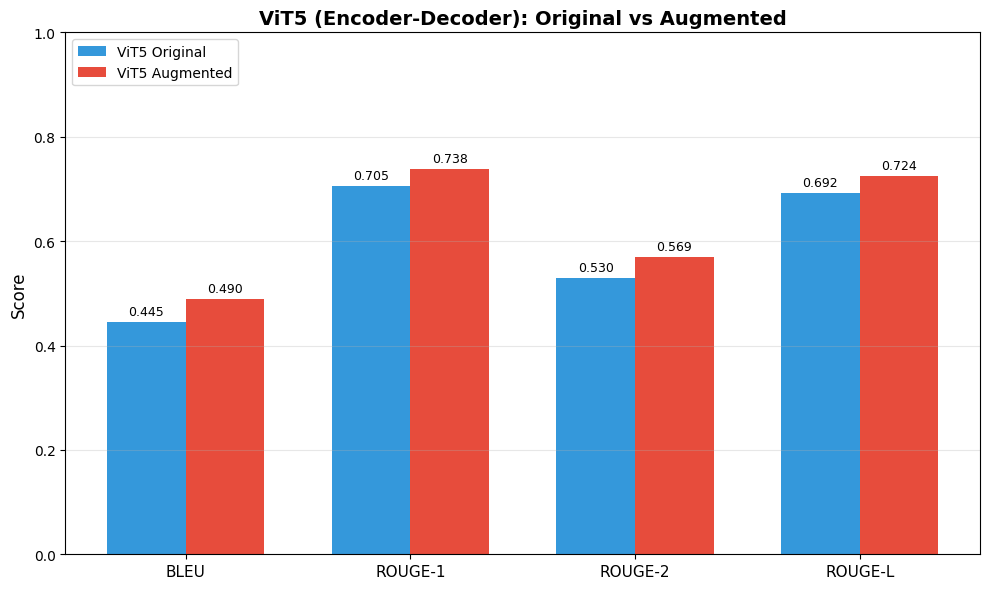

In [61]:
vit5_original = GLOBAL_RESULTS["en-de Original"]
vit5_augmented = GLOBAL_RESULTS["en-de Augmented"]

metrics = ["BLEU", "ROUGE-1", "ROUGE-2", "ROUGE-L"]
orig_values = [vit5_original[m] for m in metrics]
aug_values = [vit5_augmented[m] for m in metrics]

x = np.arange(len(metrics))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))

bars1 = ax.bar(x - width/2, orig_values, width, label='ViT5 Original', color='#3498db')
bars2 = ax.bar(x + width/2, aug_values, width, label='ViT5 Augmented', color='#e74c3c')

for bar in bars1:
    height = bar.get_height()
    ax.annotate(f'{height:.3f}',
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 3), textcoords="offset points",
                ha='center', va='bottom', fontsize=9)

for bar in bars2:
    height = bar.get_height()
    ax.annotate(f'{height:.3f}',
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 3), textcoords="offset points",
                ha='center', va='bottom', fontsize=9)

ax.set_ylabel('Score', fontsize=12)
ax.set_title('ViT5 (Encoder-Decoder): Original vs Augmented', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(metrics, fontsize=11)
ax.legend(loc='upper left', fontsize=10)
ax.set_ylim(0, 1.0)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

## So sánh PPL của Qwen (Decoder-Only)

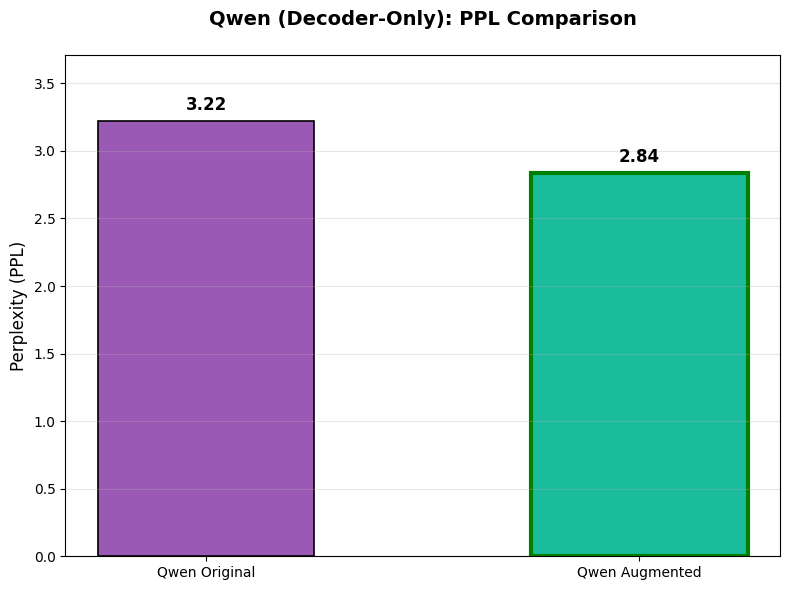

In [62]:
qwen_ppl = {
    "Qwen Original": GLOBAL_RESULTS["de1 Original"]["PPL"],
    "Qwen Augmented": GLOBAL_RESULTS["de1 Augmented"]["PPL"]
}

models = list(qwen_ppl.keys())
ppl_values = list(qwen_ppl.values())

fig, ax = plt.subplots(figsize=(8, 6))

colors = ['#9b59b6', '#1abc9c']
bars = ax.bar(models, ppl_values, color=colors, width=0.5, edgecolor='black', linewidth=1.2)

for bar in bars:
    height = bar.get_height()
    ax.annotate(f'{height:.2f}',
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 5), textcoords="offset points",
                ha='center', va='bottom', fontsize=12, fontweight='bold')

ax.set_ylabel('Perplexity (PPL)', fontsize=12)
ax.set_title('Qwen (Decoder-Only): PPL Comparison\n', fontsize=14, fontweight='bold')
ax.set_ylim(0, max(ppl_values) * 1.15)
ax.grid(axis='y', alpha=0.3)

winner_idx = ppl_values.index(min(ppl_values))
bars[winner_idx].set_edgecolor('green')
bars[winner_idx].set_linewidth(3)

plt.tight_layout()
plt.show()


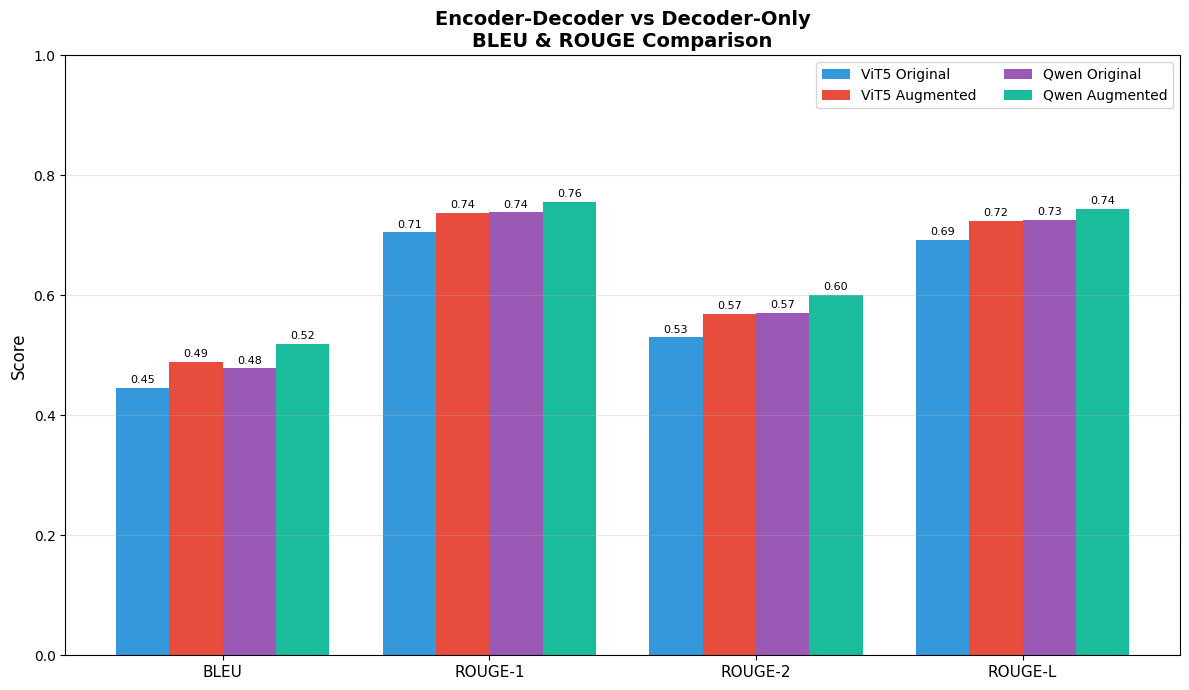

In [ ]:
results = {
    "ViT5 Original": GLOBAL_RESULTS["en-de Original"],
    "ViT5 Augmented": GLOBAL_RESULTS["en-de Augmented"],
    "Qwen Original": GLOBAL_RESULTS["de1 Original"],
    "Qwen Augmented": GLOBAL_RESULTS["de1 Augmented"],
}

metrics = ["BLEU", "ROUGE-1", "ROUGE-2", "ROUGE-L"]
models = list(results.keys())
x = np.arange(len(metrics))
width = 0.2

colors = ['#3498db', '#e74c3c', '#9b59b6', '#1abc9c']

fig, ax = plt.subplots(figsize=(12, 7))

for i, (model, scores) in enumerate(results.items()):
    values = [scores[m] for m in metrics]
    bars = ax.bar(x + i * width - 1.5 * width, values, width, label=model, color=colors[i])
    
    for bar in bars:
        height = bar.get_height()
        ax.annotate(f'{height:.2f}',
                    xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0, 2), textcoords="offset points",
                    ha='center', va='bottom', fontsize=8, rotation=0)

ax.set_ylabel('Score', fontsize=12)
ax.set_title('Encoder-Decoder vs Decoder-Only\nBLEU & ROUGE Comparison', 
             fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(metrics, fontsize=11)
ax.legend(loc='upper right', fontsize=10, ncol=2)
ax.set_ylim(0, 1.0)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()